# Project 21: AI Story Continuation using Character-Level LSTM
**Objective**: Train a character-level LSTM on two distinct story corpuses (Shakespeare and Sherlock Holmes), generate continuations from prompts using greedy vs. temperature-based sampling, compare output quality, and analyze how corpus style affects the generated text.

## 1. Theoretical Background
- **Why Deep Learning?** Traditional NLP relied on hand-crafted features (n-grams, rule-based parsers) which fail to scale. Universal approximation and representation learning allow deep models to automatically learn hierarchical structures (from characters to words to syntax) directly from raw text.
- **Sequence Modeling & LSTMs**: Long Short-Term Memory (LSTM) networks address the vanishing/exploding gradient problems of Vanilla Recurrent Neural Networks (RNNs) by introducing a cell state ($C_t$) and gating mechanisms (forget gate $f_t$, input gate $i_t$, output gate $o_t$). This allows the network to selectively retain or discard long-term historical context.

In [10]:
import os
import urllib.request
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## 2. Dataset Pipeline
We load two corpuses:
1. **Shakespeare**: Poetic, archaic, high vocabulary density.
2. **Sherlock Holmes**: 19th-century detective narrative, structured, modern vocabulary.

We process the datasets at the **character level**. Character-level models have a small vocabulary size, are robust to out-of-vocabulary words, and learn the spelling and grammar from scratch, making them excellent for demonstrating representation learning.

In [11]:
SHAKESPEARE_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
SHERLOCK_URL = "https://raw.githubusercontent.com/PacktPublishing/Python-Natural-Language-Processing-Cookbook/master/Chapter01/sherlock_holmes.txt"

def download_data():
    os.makedirs('data', exist_ok=True)
    shakespeare_path = 'data/shakespeare.txt'
    sherlock_path = 'data/sherlock.txt'
    
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    
    if not os.path.exists(shakespeare_path):
        print("Downloading Shakespeare corpus...")
        req = urllib.request.Request(SHAKESPEARE_URL, headers=headers)
        with urllib.request.urlopen(req) as response, open(shakespeare_path, 'wb') as out_file:
            out_file.write(response.read())
            
    if not os.path.exists(sherlock_path):
        print("Downloading Sherlock Holmes corpus...")
        req = urllib.request.Request(SHERLOCK_URL, headers=headers)
        with urllib.request.urlopen(req) as response, open(sherlock_path, 'wb') as out_file:
            out_file.write(response.read())
            
    return shakespeare_path, sherlock_path

shakespeare_path, sherlock_path = download_data()

In [12]:
class TextDataset:
    def __init__(self, filepath, seq_length=100, max_chars=100000):
        with open(filepath, 'r', encoding='utf-8') as f:
            text = f.read()
        
        # Convert to lowercase and slice to keep training fast
        text = text[:max_chars].lower()
        self.text = text
        self.seq_length = seq_length
        
        # Vocabulary mappings
        self.chars = sorted(list(set(text)))
        self.vocab_size = len(self.chars)
        self.char_to_idx = {char: idx for idx, char in enumerate(self.chars)}
        self.idx_to_char = {idx: char for idx, char in enumerate(self.chars)}
        
        self.data_indices = [self.char_to_idx[c] for c in text]
        
    def __len__(self):
        return len(self.data_indices) - self.seq_length - 1
        
    def get_batch(self, batch_size):
        indices = np.random.randint(0, len(self) - 1, size=batch_size)
        x_batch, y_batch = [], []
        
        for idx in indices:
            x_seq = self.data_indices[idx : idx + self.seq_length]
            y_seq = self.data_indices[idx + 1 : idx + self.seq_length + 1]
            x_batch.append(x_seq)
            y_batch.append(y_seq)
            
        return torch.tensor(x_batch, dtype=torch.long), torch.tensor(y_batch, dtype=torch.long)

## 3. Model Architecture
Our network consists of:
1. **Embedding Layer**: Projects sparse character indices into dense vector space: $\mathbb{R}^{B \times T} \to \mathbb{R}^{B \times T \times E}$.
2. **LSTM Layer**: 2 layers of LSTMs processing temporal relationships and retaining long-term dependencies.
3. **Linear Decoder Layer**: Fully connected layer projecting hidden states to vocabulary logits: $\mathbb{R}^{B \times T \times H} \to \mathbb{R}^{B \times T \times V}$.

In [13]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, x, state=None):
        embed = self.embedding(x)
        out, state = self.lstm(embed, state)
        logits = self.fc(out)
        return logits, state

## 4. Optimization Pipeline
We use standard **Cross Entropy Loss** computed at each timestep. Optimization is done via **Adam** with learning rate schedule. We use **gradient clipping** at 5.0 to maintain training stability.

In [14]:
def train_model(dataset, epochs=8, batch_size=128, steps_per_epoch=80, lr=0.002):
    model = CharLSTM(dataset.vocab_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        start_time = time.time()
        
        for step in range(steps_per_epoch):
            x, y = dataset.get_batch(batch_size)
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            logits, _ = model(x)
            
            loss = criterion(logits.view(-1, dataset.vocab_size), y.view(-1))
            loss.backward()
            
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
        epoch_loss /= steps_per_epoch
        loss_history.append(epoch_loss)
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Time: {elapsed:.2f}s")
        
    return model, loss_history

## 5. Sampling Techniques
Generating text involves predicting the next character sequence step-by-step:
1. **Greedy Sampling ($T = 0$)**: Always pick $x_{t+1} = \arg\max_c P(c)$. Leads to loops and repetitive text.
2. **Temperature-based Sampling**: Adjust logits by temperature $T$: $y'_i = y_i / T$, then apply Softmax to get $P(c) \propto \exp(y'_i)$.
   - **Low $T$ (e.g., 0.2)**: Highly conservative, grammatically correct but repetitive.
   - **Moderate $T$ (e.g., 0.6)**: Good balance of creativity and grammatical structure.
   - **High $T$ (e.g., 1.5)**: Extremely chaotic, high entropy, spelling breaks down.

In [15]:
def generate_text(model, dataset, prompt, gen_length=200, temperature=1.0):
    model.eval()
    prompt = prompt.lower()
    input_indices = [dataset.char_to_idx[c] for c in prompt if c in dataset.char_to_idx]
    if len(input_indices) == 0:
        input_indices = [dataset.char_to_idx[' ']]
        
    x = torch.tensor([input_indices], dtype=torch.long).to(device)
    generated_text = prompt
    
    with torch.no_grad():
        logits, state = model(x)
        last_logits = logits[0, -1, :]
        
        if temperature == 0.0:
            char_idx = torch.argmax(last_logits).item()
        else:
            scaled_logits = last_logits / temperature
            probs = torch.softmax(scaled_logits, dim=-1)
            char_idx = torch.multinomial(probs, 1).item()
            
        char = dataset.idx_to_char[char_idx]
        generated_text += char
        
        for _ in range(gen_length - 1):
            x = torch.tensor([[char_idx]], dtype=torch.long).to(device)
            logits, state = model(x, state)
            last_logits = logits[0, -1, :]
            
            if temperature == 0.0:
                char_idx = torch.argmax(last_logits).item()
            else:
                scaled_logits = last_logits / temperature
                probs = torch.softmax(scaled_logits, dim=-1)
                char_idx = torch.multinomial(probs, 1).item()
                
            char = dataset.idx_to_char[char_idx]
            generated_text += char
            
    return generated_text

## 6. Training the Models
We train both models now and plot their cross-entropy loss histories.

In [16]:
print("--- Training on Shakespeare ---")
shakespeare_dataset = TextDataset(shakespeare_path, seq_length=100, max_chars=100000)
shake_model, shake_loss = train_model(shakespeare_dataset, epochs=8, steps_per_epoch=80)

print("\n--- Training on Sherlock Holmes ---")
sherlock_dataset = TextDataset(sherlock_path, seq_length=100, max_chars=100000)
sherlock_model, sherlock_loss = train_model(sherlock_dataset, epochs=8, steps_per_epoch=80)

--- Training on Shakespeare ---
Epoch 1/8 | Loss: 2.1700 | Time: 10.86s
Epoch 2/8 | Loss: 1.5826 | Time: 9.44s
Epoch 3/8 | Loss: 1.4107 | Time: 9.24s
Epoch 4/8 | Loss: 1.2947 | Time: 8.10s
Epoch 5/8 | Loss: 1.2064 | Time: 8.05s
Epoch 6/8 | Loss: 1.1284 | Time: 10.53s
Epoch 7/8 | Loss: 1.0581 | Time: 8.95s
Epoch 8/8 | Loss: 0.9956 | Time: 8.88s

--- Training on Sherlock Holmes ---
Epoch 1/8 | Loss: 2.3608 | Time: 8.94s
Epoch 2/8 | Loss: 1.7480 | Time: 8.70s
Epoch 3/8 | Loss: 1.5372 | Time: 8.12s
Epoch 4/8 | Loss: 1.3997 | Time: 8.04s
Epoch 5/8 | Loss: 1.2964 | Time: 10.02s
Epoch 6/8 | Loss: 1.2113 | Time: 10.75s
Epoch 7/8 | Loss: 1.1378 | Time: 11.96s
Epoch 8/8 | Loss: 1.0731 | Time: 11.20s


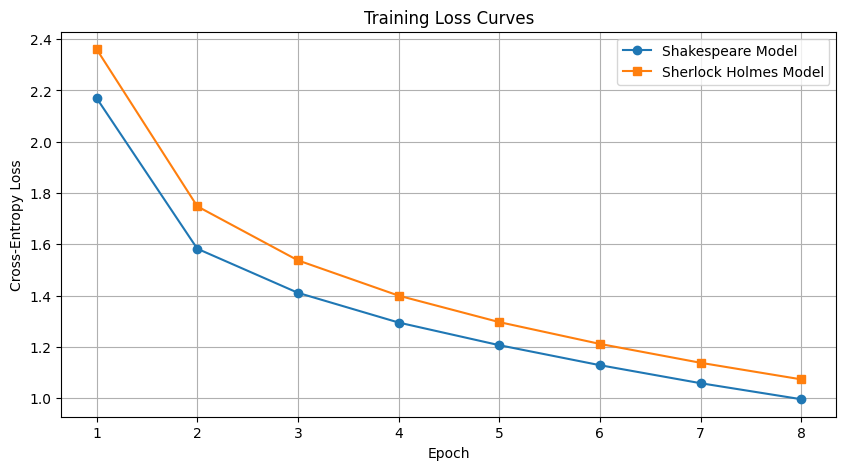

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 9), shake_loss, label='Shakespeare Model', marker='o')
plt.plot(range(1, 9), sherlock_loss, label='Sherlock Holmes Model', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

## 7. Comparative Analysis & Output Generation
We evaluate how the sampling temperature and the source corpus style affect the output quality, vocabulary, and sentence structures.

In [18]:
prompt = "the secret of "
temperatures = [0.0, 0.2, 0.6, 1.0, 1.5]

print("=== SHAKESPEARE GENERATED TEXTS ===")
for t in temperatures:
    t_label = "Greedy (T=0.0)" if t == 0.0 else f"Temp = {t}"
    out = generate_text(shake_model, shakespeare_dataset, prompt, gen_length=150, temperature=t)
    print(f"[{t_label}]:\n{out}\n" + "-"*50)

print("\n=== SHERLOCK HOLMES GENERATED TEXTS ===")
for t in temperatures:
    t_label = "Greedy (T=0.0)" if t == 0.0 else f"Temp = {t}"
    out = generate_text(sherlock_model, sherlock_dataset, prompt, gen_length=150, temperature=t)
    print(f"[{t_label}]:\n{out}\n" + "-"*50)

=== SHAKESPEARE GENERATED TEXTS ===
[Greedy (T=0.0)]:
the secret of the care to carriof, i say, the town,
the contron that he can then i a done, nor i cannot be content to the carriol'd their tongues and the care, i sh
--------------------------------------------------
[Temp = 0.2]:
the secret of the care to can it down be too than the carrious bututery, if the cannot then he come, i say, the thing, if the catress of the complesting the that th
--------------------------------------------------
[Temp = 0.6]:
the secret of this tock'd i all part you are, not aster, heelly,
that i shall be the trown after the care against a saiding,
but that i lood of corioli wear'd to ma
--------------------------------------------------
[Temp = 1.0]:
the secret of of to alls:
the gath not comin a promation.

first corniniely: corioli for him, bettend him too oppound us the think, i cencull, you let the offound a
--------------------------------------------------
[Temp = 1.5]:
the secret of cit,
fanleri